In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

from plot_config import (
    get_condition,
    apply_style,
    strip_spines,
    label_panel,
    set_n_ticks,
    save_figure,
)

apply_style()

In [2]:
# ============================================================
# CONFIG -- tunable knobs
# ============================================================

DATA_DIRS = {
    "control":      Path("/data/hdrive/phd/results/train/control/RSV90C250uM_20_p20hz"),
    "ad_3x_ryr":    Path("/data/hdrive/phd/results/train/AD/RSV90C750uM_20_p20hz_3xryr"),
    "ad_third_ryr": Path("/data/hdrive/phd/results/train/AD/RSV90C750uM_20_p20hz_1_3xryr"),
}

N_PULSES         = 20
FREQ_HZ          = 20
FIRST_PULSE_TIME = 0.002  # s

FIGSIZE   = (14, 4)
SAVE_PATH = Path("/data/hdrive/phd/AD-presynaptic-calcium-model/figures/outputs/figS3_RyR_train_0_8_serca.png")

MARKERSIZE  = 6
CAPSIZE     = 3
ELINEWIDTH  = 1.2
N_TICKS     = 3
PULSE_XTICKS = [1, N_PULSES // 2, N_PULSES]

In [3]:
# ============================================================
# DATA-LOADING HELPERS
# ============================================================

def load_trace(fname):
    data = np.loadtxt(fname)
    return data[:, 0], data[:, 1]


def load_ryr_flux(fname):
    """col0=time(s), col1=outflux, col2=influx; net = outflux - influx."""
    data = np.loadtxt(fname)
    return data[:, 0], data[:, 1] - data[:, 2]


def load_result(fname):
    """(2, 40): row0=means, row1=stds; first 20 = Pr, last 20 = Facilitation."""
    d = np.loadtxt(fname)
    return {
        "pr_mean":  d[0, :20],
        "pr_sd":    d[1, :20],
        "fac_mean": d[0, 20:],
        "fac_sd":   d[1, 20:],
    }


def _pulse_windows(first_pulse_time, freq, n_pulses, t_end):
    isi    = 1.0 / freq
    starts = first_pulse_time + np.arange(n_pulses) * isi
    ends   = np.append(starts[1:], t_end)
    return starts, ends


def extract_pulse_peaks(time, trace, first_pulse_time, freq, n_pulses):
    starts, ends = _pulse_windows(first_pulse_time, freq, n_pulses, time[-1])
    peaks = []
    for t0, t1 in zip(starts, ends):
        mask = (time >= t0) & (time < t1)
        peaks.append(np.max(trace[mask]) if np.any(mask) else np.nan)
    return np.asarray(peaks)

In [4]:
# ============================================================
# LOAD DATA
# ============================================================

pulses = np.arange(1, N_PULSES + 1)
data   = {}

for key, directory in DATA_DIRS.items():
    t_er, er   = load_trace(directory / "er_ca_conc.dat")
    t_ryr, ryr = load_ryr_flux(directory / "ryrCaFlux.dat")
    result     = load_result(directory / "result")

    data[key] = {
        "er_peak":       extract_pulse_peaks(t_er, er, FIRST_PULSE_TIME, FREQ_HZ, N_PULSES),
        "ryr_flux_t_ms": t_ryr * 1000.0,
        "ryr_flux":      ryr / 100.0,   # -> x100 molecules/s
        **result,
    }

Saved to /data/hdrive/phd/AD-presynaptic-calcium-model/figures/outputs/figS3_RyR_train_0_8_serca.png


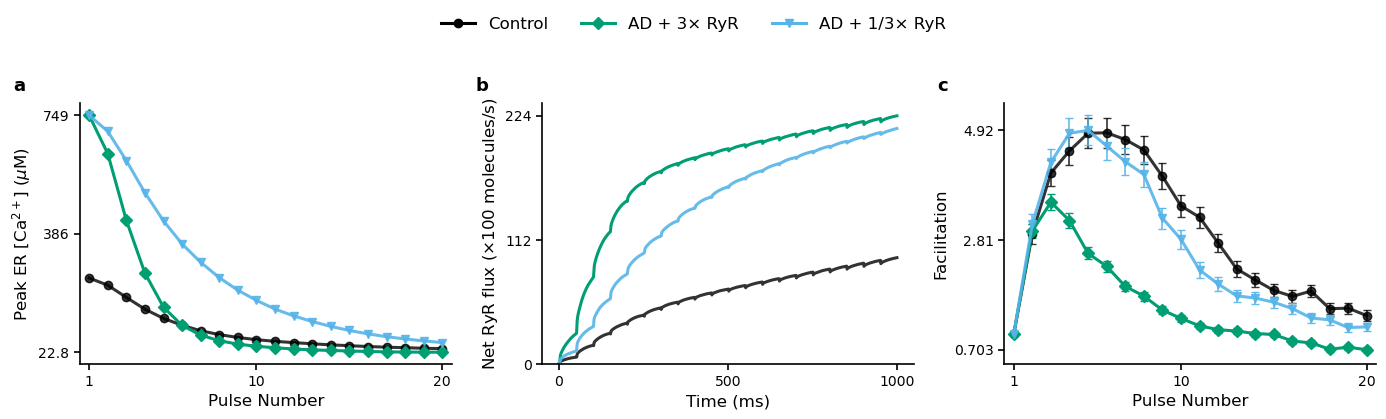

In [5]:
# ============================================================
# FIGURE  (panels a, b, c -- horizontal layout)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE)

# ---------- panel a: Peak ER [Ca2+] vs Pulse Number ----------
ax = axes[0]
for key in DATA_DIRS:
    cond = get_condition(key)
    ax.plot(
        pulses, data[key]["er_peak"],
        color=cond.color, linestyle="-", marker=cond.marker,
        markersize=MARKERSIZE, alpha=cond.alpha, zorder=cond.zorder,
    )
ax.set_xlabel("Pulse Number")
ax.set_ylabel(r"Peak ER [Ca$^{2+}$] ($\mu$M)")
ax.set_xticks(PULSE_XTICKS)
ax.set_xlim(pulses.min() - 0.5, pulses.max() + 0.5)
er_all = np.concatenate([data[k]["er_peak"] for k in DATA_DIRS])
set_n_ticks(ax, er_all.min(), er_all.max(), n=N_TICKS, axis="y")
strip_spines(ax)
label_panel(ax, "a")

# ---------- panel b: Net RyR flux vs Time ----------
ax = axes[1]
for key in DATA_DIRS:
    cond = get_condition(key)
    ax.plot(
        data[key]["ryr_flux_t_ms"], data[key]["ryr_flux"],
        color=cond.color, linestyle="-",
        alpha=cond.alpha, zorder=cond.zorder,
    )
ax.set_xlabel("Time (ms)")
ax.set_ylabel(r"Net RyR flux ($\times$100 molecules/s)")
all_t = np.concatenate([data[k]["ryr_flux_t_ms"] for k in DATA_DIRS])
set_n_ticks(ax, all_t.min(), all_t.max(), n=N_TICKS, axis="x")
all_y_ryr = np.concatenate([data[k]["ryr_flux"] for k in DATA_DIRS])
set_n_ticks(ax, max(0.0, all_y_ryr.min()), all_y_ryr.max(), n=N_TICKS, axis="y")
ax.set_ylim(bottom=0)
strip_spines(ax)
label_panel(ax, "b")

# ---------- panel c: Facilitation vs Pulse Number ----------
ax = axes[2]
for key in DATA_DIRS:
    cond = get_condition(key)
    ax.errorbar(
        pulses, data[key]["fac_mean"], yerr=data[key]["fac_sd"],
        color=cond.color, marker=cond.marker, linestyle=cond.linestyle,
        markersize=MARKERSIZE, capsize=CAPSIZE, elinewidth=ELINEWIDTH,
        alpha=cond.alpha, zorder=cond.zorder,
    )
ax.set_xlabel("Pulse Number")
ax.set_ylabel("Facilitation")
ax.set_xticks(PULSE_XTICKS)
ax.set_xlim(pulses.min() - 0.5, pulses.max() + 0.5)
fac_all = np.concatenate([data[k]["fac_mean"] for k in DATA_DIRS])
set_n_ticks(ax, fac_all.min(), fac_all.max(), n=N_TICKS, axis="y")
strip_spines(ax)
label_panel(ax, "c")

# Single-row legend above the figure
condition_handles = [
    Line2D([0], [0], color=get_condition(k).color, marker=get_condition(k).marker,
           linestyle="-", markersize=MARKERSIZE, label=get_condition(k).label)
    for k in DATA_DIRS
]
fig.legend(
    handles=condition_handles, loc="upper center", ncol=len(DATA_DIRS),
    frameon=False, bbox_to_anchor=(0.5, 1.06),
)

plt.tight_layout(rect=(0, 0, 1, 0.92))

save_figure(fig, SAVE_PATH)
print(f"Saved to {SAVE_PATH}")

plt.show()